In [19]:
import json
import random
import csv
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
categories=["Filename","Arr_name","Gender","Age","Width","Height","X_min","X_max","Y_min","Y_max","Peace","Affection","Esteem","Anticipation","Engagement","Confidence","Happiness","Pleasure",
      "Excitement","Surprise","Sympathy","Doubt/Confusion","Disconnection","Fatigue","Embarrassment",
      "Yearning","Disapproval","Aversion","Annoyance","Anger","Sensitivity","Sadness","Disquietment","Fear","Pain","Suffering"]

all_data = json.load(open('./raw_data.json', 'r'))
for row in all_data:
    for item in row['items']:
        for key in categories:
            del item[key]
        del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()
f = open('raw_data_emotic.json','w')
f.write(json.dumps(all_data))
f.close()

In [21]:
all_data = json.load(open('./raw_data_emotic.json', 'r'))

In [22]:
len(all_data)

241

In [23]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_p=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 231
Data: 3465
Workers: 205


In [26]:
np.mean([row['paramoji']['iteration'] > 1.0 for row in data])

0.2077922077922078

In [27]:
faces_no = len(set([row['Crop_name'] for row in data]))
print(f"{len(data)}/{faces_no} = {len(data)/faces_no}")

3465/199 = 17.412060301507537


In [28]:
dims=["Valence","Arousal","Dominance"]
categories=["Peace","Affection","Esteem","Anticipation","Engagement","Confidence","Happiness","Pleasure",
      "Excitement","Surprise","Sympathy","Doubt/Confusion","Disconnection","Fatigue","Embarrassment",
      "Yearning","Disapproval","Aversion","Annoyance","Anger","Sensitivity","Sadness","Disquietment","Fear","Pain","Suffering"]
paramoji_dims=['paramoji_v','paramoji_a1','paramoji_a2','paramoji_p','paramoji_c']

In [29]:
results = pd.DataFrame(data) \
    .groupby('Crop_name')[dims + paramoji_dims] \
    .median().reset_index()
results

,Crop_name,Valence,Arousal,Dominance,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c
0,crop_arr_test_1165.npy,3.500000,3.500000,5.000000,0.4714,0.22430,0.18860,0.32640,0.0000
1,crop_arr_test_1319.npy,6.666666,4.000000,6.000000,0.8126,0.70720,0.64145,0.48245,0.0000
2,crop_arr_test_1370.npy,6.000000,4.333334,5.333334,0.6898,0.45300,0.25720,0.35150,0.0000
3,crop_arr_test_1374.npy,6.666666,4.666666,7.666666,0.7761,0.51900,0.28860,0.42010,0.0000
4,crop_arr_test_1520.npy,5.000000,5.000000,7.000000,0.6253,0.56565,0.57520,0.47115,0.0000
...,...,...,...,...,...,...,...,...,...
194,crop_arr_train_930.npy,2.000000,10.000000,10.000000,0.6266,0.63920,0.87060,0.38550,0.0871
195,crop_arr_train_9620.npy,4.000000,5.000000,3.000000,0.3700,0.43450,0.10530,0.47640,0.0000
196,crop_arr_train_9701.npy,5.000000,3.000000,7.000000,0.4239,0.64870,0.12820,0.44500,0.0000
197,crop_arr_train_9805.npy,6.000000,3.000000,8.000000,0.8092,0.51330,0.28180,0.37520,0.0000


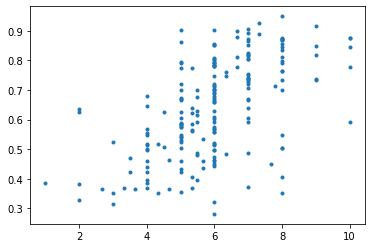

In [30]:
plt.plot(results['Valence'],results['paramoji_v'],'.')

In [31]:
C = results.corr()
C

,Valence,Arousal,Dominance,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c
Valence,1.000000,0.049256,0.200992,0.570576,-0.010421,0.357777,0.192632,-0.084849
Arousal,0.049256,1.000000,0.418306,-0.150139,0.100279,0.115644,0.154439,0.065060
Dominance,0.200992,0.418306,1.000000,0.072092,0.165674,0.137768,0.157478,0.088015
paramoji_v,0.570576,-0.150139,0.072092,1.000000,-0.016221,0.333027,0.053746,-0.176666
paramoji_a1,-0.010421,0.100279,0.165674,-0.016221,1.000000,0.066489,0.109263,-0.023293
paramoji_a2,0.357777,0.115644,0.137768,0.333027,0.066489,1.000000,0.208447,0.058091
paramoji_p,0.192632,0.154439,0.157478,0.053746,0.109263,0.208447,1.000000,0.109062
paramoji_c,-0.084849,0.065060,0.088015,-0.176666,-0.023293,0.058091,0.109062,1.000000


In [32]:
f = open('gen/emotic/results.json','w')
f.write(results.to_json(orient='records'))
f.close()

# Published data

In [37]:
print(C[paramoji_dims].loc[dims].to_latex( float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
{} &  paramoji\_v &  paramoji\_a1 &  paramoji\_a2 &  paramoji\_p &  paramoji\_c \\
\midrule
Valence   &        0.57 &        -0.01 &         0.36 &        0.19 &       -0.08 \\
Arousal   &       -0.15 &         0.10 &         0.12 &        0.15 &        0.07 \\
Dominance &        0.07 &         0.17 &         0.14 &        0.16 &        0.09 \\
\bottomrule
\end{tabular}



In [35]:
published = ['crop_arr_train_17022.npy', 'crop_arr_train_9210.npy', 'crop_arr_test_3959.npy']
M = results.loc[[row in published for row in results['Crop_name']]]
for i in range(M.shape[0]):
    row=M.iloc[i]
    print(f"%{row['Crop_name']}")
    file = [r['file'] for r in data if r['Crop_name'] == row['Crop_name']][0]
    print(f"\\face{{{file.replace('.jpg','')}}} &")
    v=row["paramoji_v"]*100
    a1=row["paramoji_a1"]*100
    a2=row["paramoji_a2"]*100
    p=row["paramoji_p"]*100
    c=row["paramoji_c"]*100
    print(f"\\paramoji{{{v:.0f},{(a1+a2)/2:.0f},{p:.0f},{c:.0f},{(a2-a1)/2+50:.0f}}} &")
    print(f"{v:.0f},{a1:.0f},{a2:.0f},{p:.0f},{c:.0f} \\\\")

%crop_arr_test_3959.npy
\face{emotic/images/img_arr_21157} &
\paramoji{62,45,44,0,35} &
62,60,29,44,0 \\
%crop_arr_train_17022.npy
\face{emotic/images/img_arr_12293} &
\paramoji{35,37,50,1,34} &
35,54,21,50,1 \\
%crop_arr_train_9210.npy
\face{emotic/images/img_arr_6662} &
\paramoji{66,64,30,0,54} &
66,60,67,30,0 \\


In [192]:
# Check faces

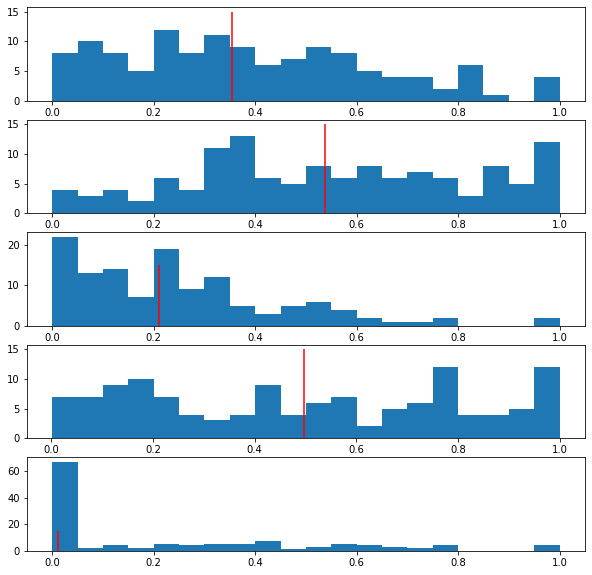

In [197]:
face="crop_arr_train_17022.npy"
DATA= [row for row in data if row['Crop_name']==face]
fig, ax = plt.subplots(5,1, figsize=(10,10))
for i in range(5):
    values = [row['paramoji']['value'][i] for row in DATA]
    ax[i].hist(values,20)
    ax[i].vlines(np.median(values), 0, 15, 'red')